In [ ]:
import matplotlib.pyplot as plt
from konlpy.tag import Kkma
from konlpy.utils import pprint
import re
from konlpy.tag import Okt
from wordcloud import WordCloud

## 1. K팝 데몬 헌터스에 대한 온라인 데이터를 분석하여 팬덤 형성의 핵심 요인을 분석

### 네이버 검색을 통한 데이터 수집

In [3]:
# 네이버 검색 API 예제 - 블로그 검색
import os
import urllib.request
from dotenv import load_dotenv
import pandas as pd
import json
import urllib.parse

load_dotenv()
client_id = os.getenv("client_id")
client_secret = os.getenv("client_secret")
if not client_id or not client_secret:
    raise ValueError("NAVER_CLIENT_ID / NAVER_CLIENT_SECRET 환경변수가 없습니다. (.env 확인)")

display_count=100
num_data=1000
sort='date'

encText = urllib.parse.quote("K팝 데몬 헌터스")
results=[]
for idx in range(1,num_data+1,display_count):
    url = "https://openapi.naver.com/v1/search/news?query=" + encText \
         +f"&start={idx}&display={display_count}&sort={sort}" # JSON 결과
# url = "https://openapi.naver.com/v1/search/blog.xml?query=" + encText # XML 결과
    request = urllib.request.Request(url)
    request.add_header("X-Naver-Client-Id",client_id)
    request.add_header("X-Naver-Client-Secret",client_secret)
    response = urllib.request.urlopen(request)
    rescode = response.getcode()
    if(rescode==200):
        response_body = response.read()
        response_dict=json.loads(response_body.decode('utf-8'))
        results=results+response_dict['items']
    else:
        print("Error Code:", rescode)
print(f'총 데이터 개수:{len(results)}')


ModuleNotFoundError: No module named 'dotenv'

In [ ]:
results[:1]

[{'title': '[2025 유통업계 결산] 생존 위한 리셋의 해…격변 속 ‘구조 재설계’ 총...',
  'originallink': 'https://www.mydaily.co.kr/page/view/2025121510483715962',
  'link': 'https://n.news.naver.com/mnews/article/117/0004017682?sid=103',
  'description': '식품업계에서는 CJ, 농심, 오뚜기 등이 <b>K</b>-<b>팝</b> 아티스트 협업 패키지를 앞세워 북미와 동남아 시장에서 판매량을 끌어올렸고, 특히 농심은 넷플릭스 애니메이션 ‘케이<b>팝 데몬 헌터스</b>’ 협업 마케팅을 펼쳐 해외 비중을... ',
  'pubDate': 'Mon, 15 Dec 2025 11:17:00 +0900'}]

In [ ]:
from datetime import datetime
import re

df=pd.DataFrame()
remove_tags=re.compile(r'<.*?>')#HTML 태그 제거를 위한 정규표현식

for item in results:
    new_data=pd.DataFrame(
        data={
            'pubDate':datetime.strptime(item['pubDate'],"%a, %d %b %Y %H:%M:%S +0900"),
            'title':re.sub(remove_tags, '',item['title']),
            'description':re.sub(remove_tags, '',item['description'])
        },
        index=[0]
    )
    df=pd.concat([df,new_data],ignore_index=True)
df.head()

,pubDate,title,description
0,2025-12-15 11:17:00,[2025 유통업계 결산] 생존 위한 리셋의 해…격변 속 ‘구조 재설계’ 총...,"식품업계에서는 CJ, 농심, 오뚜기 등이 K-팝 아티스트 협업 패키지를 앞세워 북미..."
1,2025-12-15 10:44:00,"TIOT·키라스, 인사동서 플래시몹...외국인 관광객들 K팝 체험",이날 퍼포먼스는 글로벌 팬들에게 친숙한 케이팝데몬헌터스(K-Pop Demon Hun...
2,2025-12-15 09:40:00,2025년 결산: 질주하는 넷플릭스와 딜레마에 빠진 K콘텐츠 [김희경의 컬...,넷플릭스의 오리지널 콘텐츠 ‘케이팝 데몬 헌터스’(이하 케데헌)가 예상 밖의 글로벌...
3,2025-12-15 09:36:00,[모인의 게임의 법칙]2025년 한 해를 보내면서 ...,하반기 뒤늦게 터져 나온 '케이팝 데몬 헌터스'가 거센 돌풍을 일으키고 있는 가운데...
4,2025-12-15 07:05:00,"테일러 스위프트, 美 '빌보드200' 통산 9주 1위…케데헌 3위·스키즈 10위",글로벌 신드롬이 여전한 넷플릭스 애니메이션 영화 '케이팝 데몬 헌터스(K-Pop D...


In [ ]:
df.to_csv('DemonHunters.csv', index=False, encoding='utf-8')

{"we've", 'few', 'which', 'she', 'theirs', 'quot', 'on', '다시', 'hence', "that's", 'does', "hadn't", "they'd", "what's", '그', 'such', 'some', 'been', 'would', '있게', "mustn't", '다소', 'can', 'then', "you've", '에서', '와', 'again', 'between', 'get', '한다', '항상', '데몬', 'of', 'his', 'to', '등', '저기', 'each', 'up', '누구', "hasn't", '을', 'too', 'since', 'there', '정말', '이미', 'K팝', '로', '은', 'after', "didn't", 'its', 'and', "haven't", "she's", 'below', "weren't", '가장', '등을', '케이팝', 'otherwise', '하지만', '등등', '수', '그러나', "you'd", '누가', "she'll", 'ourselves', '만', 'over', 'we', 'yours', 'myself', '하였다', 'hers', '으로', '또는', 'down', '할', 'out', 'for', "i'd", 'he', '약간', 'an', '이', 'who', 'above', 'be', 'before', 'being', 'whom', '이다', "they're", 'by', 'itself', 'ours', 'until', '관련', "can't", 'at', "he'll", 'that', "i've", 'into', 'i', 'my', '더', '된다', "wouldn't", 'them', 'however', 'has', 'why', "it's", 'other', 'from', 'having', "when's", '경우', 'these', 'therefore', 'here', '입니다', '또', 'doing', 'is', '저

['C:\\Windows\\Fonts\\LSANS.TTF',
 'C:\\Windows\\Fonts\\VLADIMIR.TTF',
 'C:\\Windows\\Fonts\\GILI____.TTF',
 'C:\\Windows\\Fonts\\LTYPE.TTF',
 'C:\\Windows\\Fonts\\ROCKBI.TTF',
 'C:\\Windows\\Fonts\\FRABKIT.TTF',
 'C:\\Windows\\Fonts\\AGENCYB.TTF',
 'C:\\Windows\\Fonts\\consolab.ttf',
 'C:\\Users\\paint\\AppData\\Local\\Microsoft\\Windows\\Fonts\\codicon-0.0.35.ttf',
 'C:\\Windows\\Fonts\\ARIALN.TTF']

In [ ]:
import re

# 텍스트 정제를 위한 함수 정의
def cleanString(text):

    pattern = r"""['"]?([a-z0-9_.+-]+)@([a-z0-9-]+)\.([a-z.]{2,6})['"]?"""
    text = re.sub(pattern=pattern, repl='', string=text)

    # 한글 자음, 모음 제거
    # [ㄱ-ㅎㅏ-ㅣ]+ : 자음 또는 모음이 1개 이상 반복
    pattern = r'[ㄱ-ㅎㅏ-ㅣ]+'
    text = re.sub(pattern=pattern, repl='', string=text)

    # HTML 태그 제거
    # <.*?> : <로 시작하고 >로 끝나는 모든 문자열
    pattern = r'<.*?>'
    text = re.sub(pattern=pattern, repl='', string=text)

    # 특수문자 제거
    # [^\w\s\n] : 영문 대소문자, 숫자, 개행문자가 아닌 문자
    pattern = r'[^\w\s\n]'
    text = re.sub(pattern=pattern, repl='', string=text)

    return text


# 텍스트 정제
text=cleanString(text)


In [ ]:
def showwordCloudBasic(wc):
    plt.figure(figsize=(7,4))
    plt.imshow(wc)
    plt.axis('off')
    plt.show()

words_kor=WordCloud(
    max_words=50,
    font_path=han_font_path,
    stopwords=STOPWORDS,
    width=800,
    height=800,
    background_color='white',
    colormap='viridis'
).generate(text)

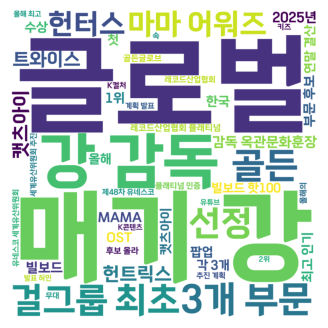

In [ ]:
showwordCloudBasic(words_kor)

In [ ]:
text

'2025 유통업계 결산 생존 위한 리셋의 해격변 속 구조 재설계 총 TIOT키라스 인사동서 플래시몹외국인 관광객들 K팝 체험 2025년 결산 질주하는 넷플릭스와 딜레마에 빠진 K콘텐츠 김희경의 컬 모인의 게임의 법칙2025년 한 해를 보내면서  테일러 스위프트 美 빌보드200 통산 9주 1위케데헌 3위스키즈 10위 ASH 2025 미국혈액학회 현장에서도 K컬쳐는 통했다 케데헌 이재 음악한 이유 공부시키려면 이 털 뽑아줘야 5성급리조트에 퍼진 골든K팝 침투한 필리핀 크리스마스 점등식 현 아침마당 문화관광산업 활성화를 위한 관련기관의 역할 K팝 듣다가 한국 음식화장품에 빠진 지 10년말레이시아 일상 스 평균 나이 50세 제2의 전성기 맞은 국민과자들의 장수 비결은 국가 정상화 새 정부 출범코스피 4000 시대 뉴스1 선정 국내 10대뉴 나도 유튜브나 해볼까 했다가 조회수 10 폭망핵심 키워드 알아야 K애니의 부재 주토피아2 케데헌이 탄생하지 못하는 이유 quotK팝 저력 입증quot 케데헌 OST 英 싱글 차트 3곡 동시 진입 케데헌 OST 3곡 英 싱글차트 차트인 유지골든 22위 황대호 위원장 quot경기도 K컬처산업 육성에 새 이정표 될 것으로 기대quot 빌보드 석권 케데헌 한국 노래방 순위는 TIOT키라스 관광객과 만난 깜짝 플래시몹인사동 쌈지길에 펼쳐 전통현대 어우러진 K아트의 향연 美 심장을 수놓다 조상인의 미담 엔터 지금 정작 한국엔 없는 K팝 축제 시상식이 해외로 향하는 속사 케데헌서 발견한 K정신문화 quot세계가 영감 얻는 문화관광 대국 중심 돼 센터엔터 주사이모 친분설 온유 quot피부관리 받았을 뿐quot 外 quot엔믹스부터 제니지드래곤까지quot英 NME 결산 K팝 3색진화 조명 독일에서 주목받는 K소비재 Korea 팝업 페스티벌 개최기 대구정책연구원 DPI 정책세미나 개최quotK컬처시대 대구형 한류 브랜드 강호동 울린 26년 남매 교실 투명인간 이래서 버텼다 에버랜드에 케데헌 매기 강 감독 떴다테마존불꽃쇼 즐기고 돌아 경기도의회 황대

In [ ]:
#형태소 분리 후 명사, 동사, 형용사만
okt=Okt()
text_pos=okt.pos(text)
words=[word for word, pos in text if pos in ['Noun','Verb','Adjective']]
print(words)

ValueError: not enough values to unpack (expected 2, got 1)